[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/NguyenVu04/band-tilt/blob/main/notebooks/03b_turbo.ipynb)

# 03b — Bayesian Optimization with TuRBO

**Question.** Does a model-guided search find better tilts than the baselines for the same number of evaluations?

**Method.** TuRBO-1 (Eriksson et al., 2019): a Gaussian process fitted to the weighted KPI score, Thompson
sampling inside one trust region around the best point, and a restart when the region collapses.
Every candidate is ray-traced; no score comes from the surrogate.

**Outputs.** One run directory per seed under `outputs/optim/turbo/`.
**Requirements.** A CUDA GPU, and notebook 03a run first.

In [1]:
# Environment: locally, move to the project root; on Colab, clone the repository
# and install what Colab lacks. Extra Hydra overrides come from BAND_TILT_OVERRIDES.
REPO_URL = "https://github.com/NguyenVu04/band-tilt.git"
COLAB_PACKAGES = [("hydra", "hydra-core"), ("sionna.rt", "sionna-rt"), ("botorch", "botorch")]

import importlib.util
import os
import subprocess
import sys
from pathlib import Path

try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    root = Path("/content/band-tilt")
    if not root.exists():
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, str(root)], check=True)
    missing = [pip for module, pip in COLAB_PACKAGES if importlib.util.find_spec(module) is None]
    if missing:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)
else:
    root = Path.cwd()
    while not (root / "pyproject.toml").exists() and root != root.parent:
        root = root.parent

os.chdir(root)
sys.path.insert(0, str(root))
CONFIG_OVERRIDES = os.environ.get("BAND_TILT_OVERRIDES", "").split()

In [2]:
%load_ext autoreload
%autoreload 2

from functools import partial

import matplotlib.pyplot as plt
import pandas as pd

from src.config import load_config
from src.evaluation import compare, plots
from src.evaluation import runs as run_store
from src.evaluation.export import readable, save_table
from src.optim.run import run
from src.optim.space import TiltSpace
from src.utils.plotting import save_fig, setup_plotting
from src.utils.seed import set_seed

cfg = load_config(overrides=CONFIG_OVERRIDES)
set_seed(cfg.seed)
setup_plotting()
save_fig = partial(save_fig, in_colab=IN_COLAB, directory=Path("reports/figures/03b_turbo"))
save_table = partial(save_table, in_colab=IN_COLAB, directory=Path("reports/tables/03b_turbo"))
pd.set_option("display.precision", 4)
pd.set_option("display.max_columns", 40)

# Search seeds, matched to 03a: optim.seed from the config; BAND_TILT_SEEDS overrides it.
SEEDS = [int(seed) for seed in os.environ.get("BAND_TILT_SEEDS", str(cfg.optim.seed)).split()]
# Solver seeds for the noise re-trace in section 3, distinct from the one every run selected under.


## 1. Runs

A run already on disk for the same seed is reused; delete its directory under `outputs/optim/turbo/` to repeat it.

In [3]:
def on_disk():
    """The newest finished run of each method and seed."""
    return run_store.latest_per_method_and_seed(run_store.discover(cfg.optim.output.dir))


done = {(r.method, r.seed) for r in on_disk()}
for seed in SEEDS:
    if ("turbo", seed) not in done:
        run(load_config(overrides=["optim/method=turbo", f"optim.seed={seed}", *CONFIG_OVERRIDES]))

runs = [
    candidate for candidate in on_disk() if candidate.seed in SEEDS or candidate.method == "rule"
]
turbo_results = readable(
    compare.method_table([r for r in runs if r.method == "turbo"], cfg).drop(columns=["run"])
)
save_table(turbo_results, "turbo_results")
turbo_results

jitc_llvm_init(): LLVM API initialization failed ..



turbo: 8 solutions published

 solution  recommended  score  hole_rate  overlap_rate  served_ratio  weak_rate  edge_rsrp_dbm  hole_desirability  overlap_desirability  served_desirability
        0        False 0.8499     0.1768        0.3212        0.9065     0.1739      -105.9248             0.8227                0.8886               0.8568
        1         True 0.8610     0.1739        0.3161        0.9181     0.1436      -104.1787             0.8262                0.9078               0.8765
        2        False 0.8609     0.1739        0.3168        0.9185     0.1447      -104.1674             0.8261                0.9074               0.8770
        3        False 0.8609     0.1739        0.3186        0.9196     0.1442      -104.1695             0.8262                0.9070               0.8774
        4        False 0.8609     0.1739        0.3168        0.9181     0.1447      -104.2142             0.8260                0.9081               0.8756
        5        False 0.86

,Method,Seed,Evaluations,Best evaluation,Ray tracing [min],Wall clock [min],Coverage hole rate,Co-band overlap rate,Served UE ratio,Weak coverage rate,Cell-edge RSRP,Coverage desirability,Layer separation desirability,"Served desirability, per tile",Quality index,KPIs improved,KPIs worsened
0,TuRBO,42,145,140,9.4966,15.4831,0.1739,0.3161,0.9181,0.1436,-104.1787,0.8262,0.9078,0.8765,0.861,8,0


**Observations.** _To be written._

## 2. Search Progress

Best weighted score found so far, averaged over seeds; the band spans the best and worst seed.

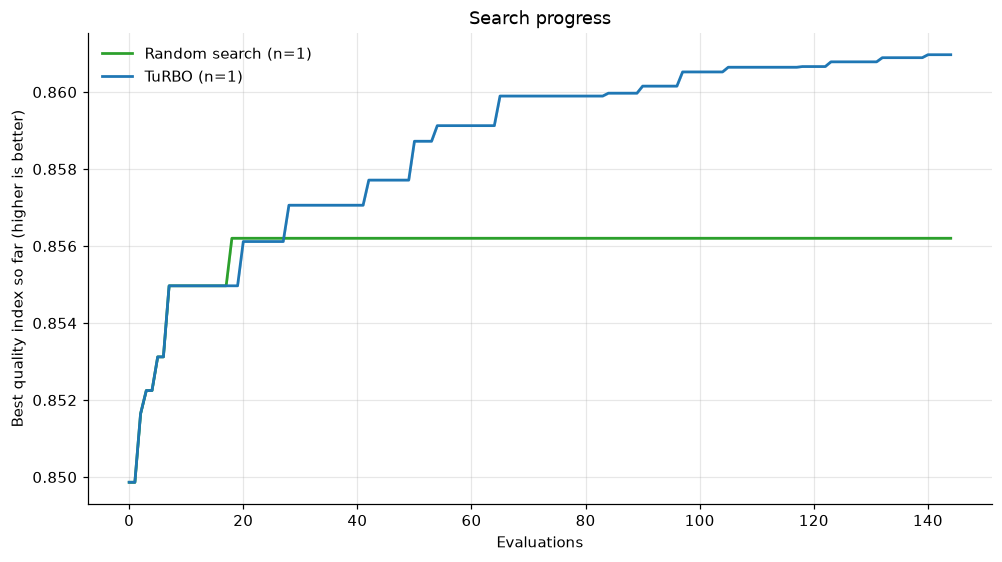

In [4]:
figure = plots.convergence_plot(
    compare.convergence([r for r in runs if r.method in ("turbo", "random")], cfg)
)
save_fig(figure, "search_progress")
plt.show()

**Observations.** _To be written._